# Eksperimen Dataset: Telco Customer Churn
**Nama:** Kristanto Winata
**Kelas:** Membangun Sistem Machine Learning (MSML) - Dicoding

Notebook ini berisi tahapan eksperimen terhadap dataset pelatihan, meliputi:
1. **Data Loading** - memuat dataset mentah
2. **Exploratory Data Analysis (EDA)** - memahami karakteristik data
3. **Data Preprocessing** - membersihkan dan mentransformasi data hingga siap latih

**Dataset:** [Telco Customer Churn](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) - data pelanggan perusahaan telekomunikasi untuk memprediksi *churn* (pelanggan berhenti berlangganan). Klasifikasi biner: `Churn = Yes/No`.

## 1. Import Library

Tahap awal: mengimpor seluruh library yang dibutuhkan untuk manipulasi data, visualisasi, dan preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)

Pandas : 2.3.3
NumPy  : 2.0.1


## 2. Data Loading

Memuat dataset mentah `Telco-Customer-Churn.csv` dari folder `telco_churn_raw` dan menampilkan beberapa baris pertama untuk memastikan data termuat dengan benar.

In [2]:
df = pd.read_csv("telco_churn_raw/Telco-Customer-Churn.csv")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()

Jumlah baris  : 7043
Jumlah kolom  : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

Tahap eksplorasi untuk memahami struktur, tipe data, distribusi, missing values, dan hubungan antar fitur sebelum melakukan preprocessing.

### 3.1 Informasi Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observasi:** Kolom `TotalCharges` terdeteksi bertipe `object` (string), padahal secara logika seharusnya numerik (total tagihan pelanggan). Ini indikasi ada nilai tidak valid yang perlu ditangani di tahap preprocessing.

### 3.2 Statistik Deskriptif

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 Pengecekan Missing Values dan Duplikat

In [5]:
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

Missing values per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Jumlah baris duplikat: 0


**Observasi:** Tidak ada missing value eksplisit (`NaN`) dan tidak ada duplikat. Namun perlu dicek apakah ada *missing value tersembunyi* berupa string kosong/spasi — terutama pada `TotalCharges` yang tipenya janggal.

In [6]:
tc_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
invalid_rows = df[tc_numeric.isnull()]
print(f"Jumlah baris TotalCharges tidak valid: {len(invalid_rows)}")
invalid_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Jumlah baris TotalCharges tidak valid: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Observasi:** Terdapat **11 baris** dengan `TotalCharges` berupa string spasi kosong. Menariknya, seluruh baris tersebut memiliki `tenure = 0` — artinya pelanggan baru yang belum pernah ditagih. Ini akan ditangani pada tahap preprocessing.

### 3.4 Distribusi Variabel Target (`Churn`)

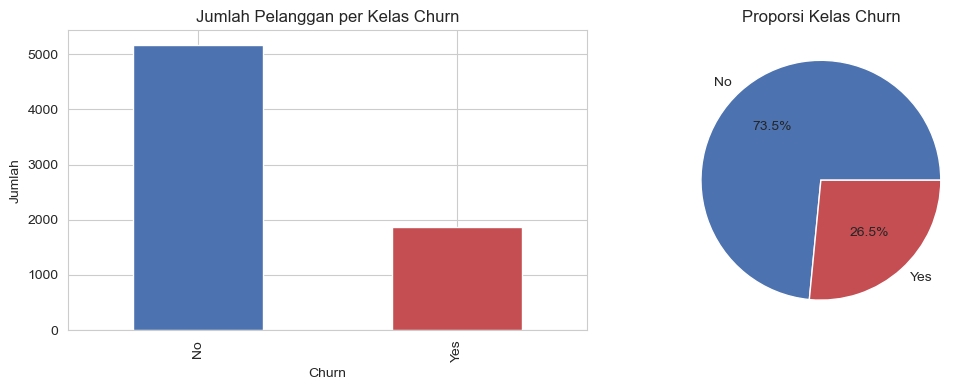

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax[0])
ax[0].set_title("Jumlah Pelanggan per Kelas Churn")
ax[0].set_xlabel("Churn"); ax[0].set_ylabel("Jumlah")
df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%",
    colors=["#4C72B0", "#C44E52"], ax=ax[1])
ax[1].set_title("Proporsi Kelas Churn"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

print(df["Churn"].value_counts())

**Observasi:** Data tidak seimbang (*imbalanced*) - sekitar 73% pelanggan tidak churn dan 27% churn. Hal ini perlu diperhatikan saat evaluasi model nanti (akurasi saja tidak cukup; metrik seperti F1-score dan recall relevan).

### 3.5 Distribusi Fitur Numerik

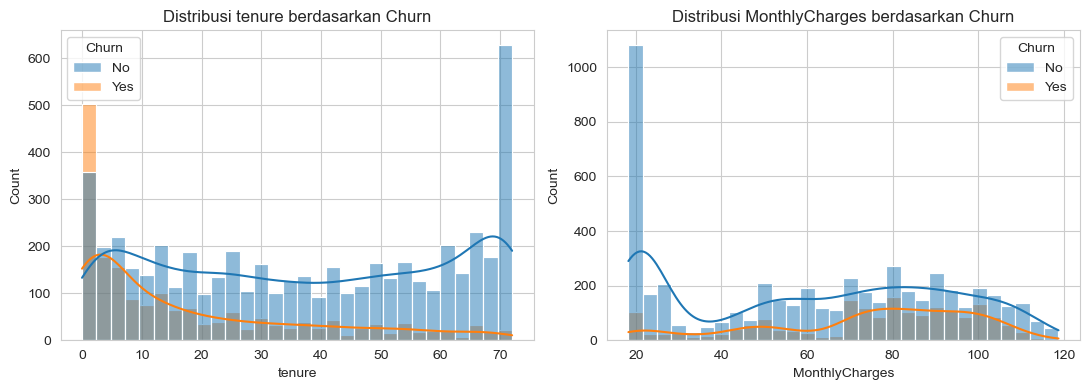

In [8]:
num_cols = ["tenure", "MonthlyCharges"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, ax=ax[i])
    ax[i].set_title(f"Distribusi {col} berdasarkan Churn")
plt.tight_layout(); plt.show()

**Observasi:** Pelanggan yang churn cenderung memiliki `tenure` rendah (pelanggan baru) dan `MonthlyCharges` tinggi. Kedua fitur ini tampak informatif untuk prediksi.

### 3.6 Hubungan Fitur Kategorikal dengan Target

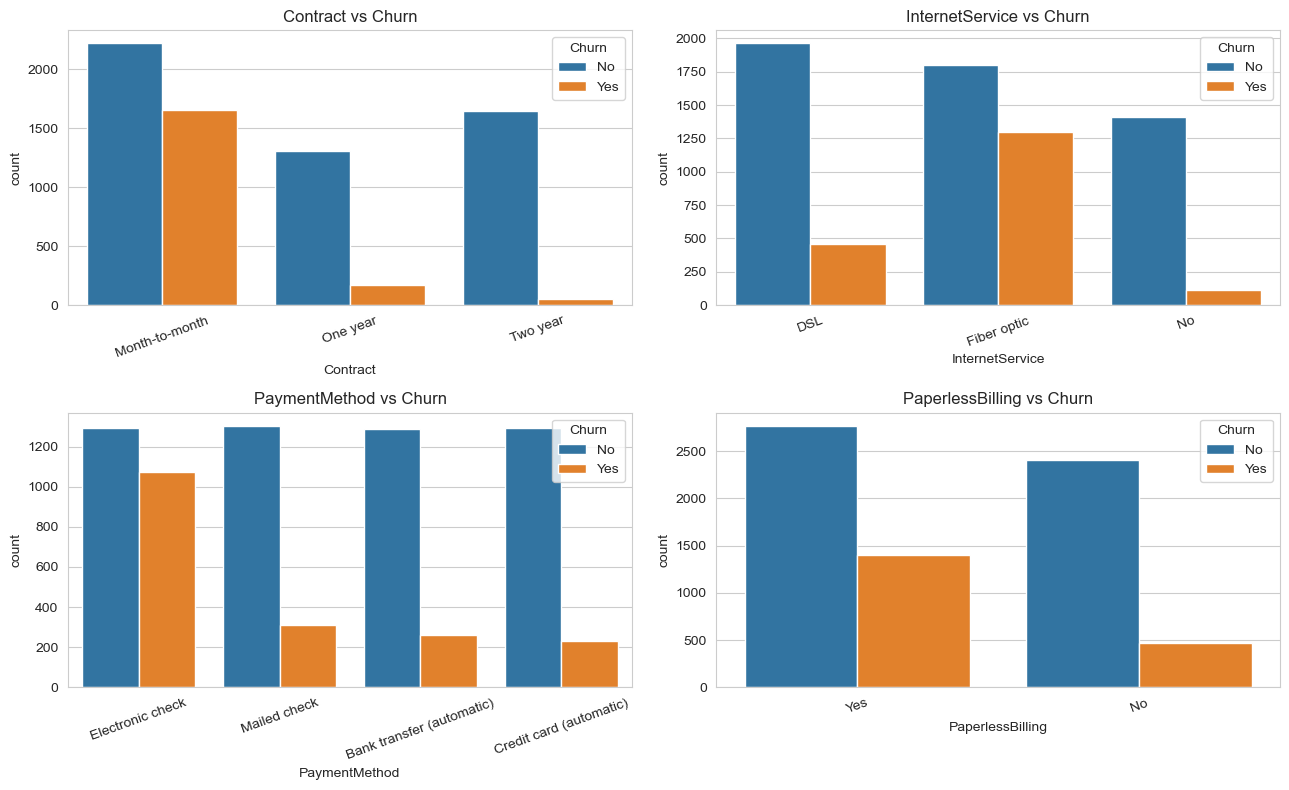

In [9]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax[i // 2][i % 2])
    ax[i // 2][i % 2].set_title(f"{col} vs Churn")
    ax[i // 2][i % 2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

**Observasi:**
- Pelanggan kontrak `Month-to-month` jauh lebih sering churn dibanding kontrak 1–2 tahun.
- Pengguna `Fiber optic` memiliki tingkat churn lebih tinggi dibanding DSL.
- Metode pembayaran `Electronic check` berasosiasi dengan churn tertinggi.

### 3.7 Korelasi Antar Fitur Numerik

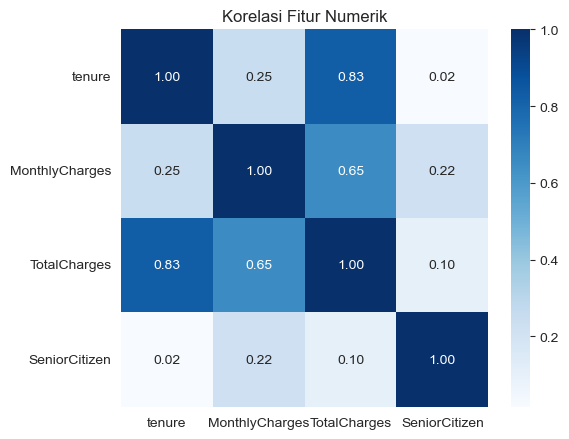

In [10]:
df_corr = df.copy()
df_corr["TotalCharges"] = pd.to_numeric(df_corr["TotalCharges"], errors="coerce")
corr = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].corr()

plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Numerik")
plt.tight_layout(); plt.show()

**Observasi:** `TotalCharges` berkorelasi sangat kuat dengan `tenure` (0.83) dan `MonthlyCharges` (0.65) - wajar karena `TotalCharges ≈ tenure × MonthlyCharges`. Informasi ini dicatat, namun ketiga fitur tetap dipertahankan.

**Ringkasan temuan EDA (dasar keputusan preprocessing):**
1. `TotalCharges` bertipe string dengan 11 nilai kosong (tenure=0) - konversi numerik + imputasi 0
2. `customerID` hanya identifier unik - dihapus
3. Fitur kategorikal perlu di-encoding, fitur numerik perlu di-scaling
4. Target `Churn` perlu dikonversi ke 0/1

## 4. Data Preprocessing

Berdasarkan temuan EDA, tahapan preprocessing yang dilakukan:
1. Perbaikan tipe data `TotalCharges` + imputasi nilai kosong
2. Penghapusan kolom `customerID`
3. Encoding target `Churn` (Yes/No - 1/0)
4. Encoding fitur kategorikal (Label Encoding untuk biner, One-Hot Encoding untuk multi-kategori)
5. Scaling fitur numerik dengan `StandardScaler`

### 4.1 Perbaikan `TotalCharges`

In [11]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Tipe data TotalCharges:", df_clean["TotalCharges"].dtype)
print("Missing tersisa:", df_clean["TotalCharges"].isnull().sum())

Tipe data TotalCharges: float64
Missing tersisa: 0


### 4.2 Penghapusan Kolom Identifier

In [12]:
df_clean = df_clean.drop(columns=["customerID"])
print("Kolom tersisa:", df_clean.shape[1])

Kolom tersisa: 20


### 4.3 Encoding Variabel Target

In [13]:
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
df_clean["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 4.4 Encoding Fitur Kategorikal

In [14]:
cat_features = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
binary_cols = [c for c in cat_features if df_clean[c].nunique() == 2]
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
print("Label Encoding :", binary_cols)

multi_cols = [c for c in cat_features if c not in binary_cols]
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True, dtype=int)
print("One-Hot Encoding:", multi_cols)
print("Jumlah kolom setelah encoding:", df_clean.shape[1])

Label Encoding : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-Hot Encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Jumlah kolom setelah encoding: 31


### 4.5 Scaling Fitur Numerik

In [15]:
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])
df_clean[scale_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
tenure,-2.421273e-17,1.000071,-1.318165,1.613701
MonthlyCharges,-6.406285e-17,1.000071,-1.545860,1.794352
TotalCharges,-3.783239e-17,1.000071,-1.005780,2.825806


### 4.6 Hasil Akhir Data Siap Latih

In [16]:
print(f"Dimensi akhir: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Dimensi akhir: 7043 baris x 31 kolom
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,...,0,0,0,0,0,0,0,0,1,0


### 4.7 Penyimpanan Dataset Hasil Preprocessing

Dataset yang telah bersih dan siap latih disimpan ke folder `telco_churn_preprocessing` untuk digunakan pada tahap pembangunan model (Kriteria 2 dan 3).

In [17]:
import os
os.makedirs("telco_churn_preprocessing", exist_ok=True)
output_path = "telco_churn_preprocessing/telco_churn_preprocessed.csv"
df_clean.to_csv(output_path, index=False)
print(f"Dataset hasil preprocessing tersimpan di: {output_path}")
print(f"Ukuran file: {os.path.getsize(output_path) / 1024:.1f} KB")

Dataset hasil preprocessing tersimpan di: telco_churn_preprocessing/telco_churn_preprocessed.csv
Ukuran file: 796.9 KB


## 5. Kesimpulan

- Dataset Telco Customer Churn berisi **7.043 pelanggan** dengan **21 kolom** (20 fitur + 1 target biner `Churn`).
- Ditemukan 11 *hidden missing values* pada `TotalCharges` (string spasi kosong pada pelanggan `tenure=0`) yang ditangani dengan konversi numerik + imputasi 0.
- Kolom `customerID` dihapus karena hanya identifier.
- Seluruh fitur kategorikal telah di-encoding (Label Encoding untuk biner, One-Hot untuk multi-kategori) dan fitur numerik telah di-scaling dengan `StandardScaler`.
- Hasil akhir: dataset **siap latih** berdimensi 7.043 × 31 tersimpan di `telco_churn_preprocessing/telco_churn_preprocessed.csv`.
- Insight utama EDA: churn didominasi pelanggan kontrak bulanan, pengguna fiber optic, pembayar electronic check, dengan tenure rendah dan tagihan bulanan tinggi. Data target imbalanced (73:27) - metrik evaluasi selain akurasi perlu diperhatikan pada tahap modelling.